# Homework 4: Deep Convolutional Generative Adversarial Network (DCGAN) (100 points)

In this assignment, we're going to build and train a DCGAN model with the help of a GPU to generate synthetic pokemon images.

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core deep learning and computer vision libraries used in this assignment.
import torch
import torchvision
import matplotlib.pyplot as plt

# nn contains the neural network building blocks used for the DCGAN.
from torch import nn

# d2l provides helper utilities for plotting, GPU selection, and image display.
from d2l import torch as d2l

# tqdm is used for progress bars during training.
from tqdm import tqdm

# zipfile is used to extract the Pokemon image dataset.
import zipfile

# assets helps locate the course data files inside the provided environment.
from mads.lib.path import assets


# Loading Data (0 points)

This is an example of using a built-in torchvision dataloader for a vision dataset, no code needed here.

The original data can be retrieved from: [Kaggle - Pokemon Image Dataset](https://www.kaggle.com/datasets/kvpratama/pokemon-images-dataset)

**Please note** that you will want to unzip the dataset (in `assets/data/pokemon.zip`) before you run this code for the first time. As the dataset is large, you may expect it to take about twenty minutes. 

In [2]:
# This cell extracts the Pokemon image dataset from the provided zip file.
# Run it once to unzip the data. After the files have been extracted successfully,
# you can comment this cell out to avoid repeating the slow extraction step.

pokemon_zip = assets.find("data/pokemon.zip")
with zipfile.ZipFile(pokemon_zip, 'r') as zip_ref:
    zip_ref.extractall(assets.find("data"))


OSError: [Errno 30] Read-only file system: '/voc/course/public/assets/data/pokemon/692/692-16.png'

In [3]:
# Load the dataset from the extracted image folder.
# ImageFolder automatically assigns labels based on folder names, although
# labels are not important for GAN training because the model learns from images only.
pokemon = torchvision.datasets.ImageFolder(assets.find("data/pokemon"))


In [4]:
# Number of images processed in each training batch.
batch_size = 256

# Define the preprocessing pipeline applied to every image:
# 1) Resize all images to 64x64 so the network sees a consistent input size.
# 2) Convert images to PyTorch tensors.
# 3) Normalize pixel values to roughly [-1, 1], which matches the generator's Tanh output.
transformer = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)
])
pokemon.transform = transformer

# Build the data loader.
# shuffle=True randomizes the image order each epoch, which improves training.
# num_workers=2 lets data loading happen in parallel for better throughput.
data_iter = torch.utils.data.DataLoader(
    pokemon, batch_size=batch_size, shuffle=True,
    num_workers=2)


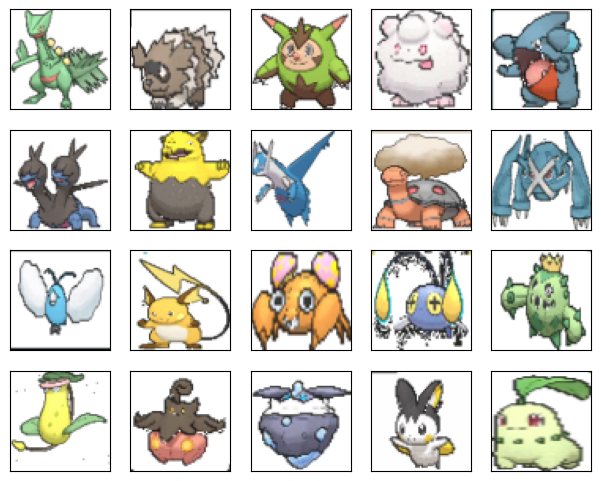

In [5]:
# Set a compact default figure size for image visualization.
plt.rcParams['figure.figsize'] = (4, 4)

# Visualize a sample batch of Pokemon images after preprocessing.
for X, y in data_iter:
    # The tensor arrives as (batch, channels, height, width).
    # For plotting, we convert it to (batch, height, width, channels).
    # We also undo the normalization by mapping values from [-1, 1] back to [0, 1].
    imgs = X[0:20, :, :, :].permute(0, 2, 3, 1) / 2 + 0.5
    d2l.show_images(imgs, num_rows=4, num_cols=5)
    break


# Question 1: Build the Generator

In this part, you will build the generator of a DCGAN. Each generator is composed of several generator blocks.

Each generator block should include a convolutional layer, batch normalization, and an activation function.

The generator then consists of 4 blocks with different input/output channels, a convolutional layer and an activation function.

Finally, we will put the blocks into an nn.Sequential module as we did in Homework 2.

You can follow the architecture proposed in the original: [Unsupervised Representation Learning
with Deep Convolutional Generative Adversarial Networks](https://arxiv.org/pdf/1511.06434.pdf)




In [ ]:
class G_block(nn.Module):
    def __init__(self, in_channels, out_channels,  kernel_size=4, stride=2,
                 padding=1, **kwargs):
        super(G_block, self).__init__(**kwargs)

        # A generator block upsamples the feature map using a transposed convolution,
        # stabilizes learning with batch normalization, and then applies ReLU
        # to introduce nonlinearity.
        self.net = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels, out_channels,
                kernel_size=kernel_size, stride=stride,
                padding=padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, X):
        # Pass the input through the generator block.
        return self.net(X)


### **Read the following implementation requirements for the Generator closely that are based on the original paper.**


### Generator Requirements
- Four G block layers followed by a nn.ConvTranspose2d layer
    - Your first Gblock layer should use a `stride=1` and `padding=0`, but the remaining Gblock layers will use all of the default arguments provided in the class (the defaults are already provided in the boiler plate code)
    - You will have to determine the correct arguments for `stride` and `kernel` for the last nn.ConvTranspose2d layer, but it is recommended you include the argument `bias=False`
- Use a tanh Activation function after the final layer in your Gblock
- The output from the first Gblock should be (512, 4, 4)
    - Each successive layer should reduce the number of channels in half, while the height and width dimensions double (i.e. (512, 4,4) -> (256, 8, 8)
    - This pattern continues until the last layer of the Generator produces an output that is (3, 64, 64)
    

**The tips and tricks notebook has additional guidance and tests you can run to validate your Generator and Discriminator models**


In [ ]:
# Build the full generator.
# Input noise has shape (batch_size, 100, 1, 1).
# Each G_block upsamples the spatial resolution until we reach a 64x64 RGB image.
net_G = nn.Sequential(
    G_block(100, 512, stride=1, padding=0),  # (100, 1, 1)   -> (512, 4, 4)
    G_block(512, 256),                       # (512, 4, 4)   -> (256, 8, 8)
    G_block(256, 128),                       # (256, 8, 8)   -> (128, 16, 16)
    G_block(128, 64),                        # (128, 16, 16) -> (64, 32, 32)

    # Final transposed convolution maps features to 3 output channels (RGB)
    # and produces the final 64x64 image.
    nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),

    # Tanh constrains the output to [-1, 1], matching the normalization used in preprocessing.
    nn.Tanh()
)

# Verify the generator output shape using a random latent input vector.
X = torch.randn(size=(1, 100, 1, 1))
print(net_G(X).shape)


In [ ]:
# assert statements to help check your solutions 

gb=G_block(100, 512)
conv_num=0
batch_norm=0
for m in gb.modules():
    conv_num+=(type(m)==nn.ConvTranspose2d)
    batch_norm+=(type(m)==nn.BatchNorm2d)
assert conv_num==1, "Question 1: Number of 2D transposed convolution operators applied in G_block class does not match expected"
assert batch_norm==1, "Question 1: Number of batch normalizations applied does not match expected"


gblock_num=0
conv_num=0
for m in net_G:
    gblock_num+=(type(m)==G_block)
    conv_num+=(type(m)==nn.ConvTranspose2d)
assert gblock_num==4, "Question 1: Number of generator blocks does not match expected"
assert conv_num==1, "Question 1: Number of 2D transposed convolution operators applied in DCGAN generator does not match expected"


# Question 2: Build the Discriminator

In this question, you will build the discriminator. Each discriminator is composed of several discriminator blocks.

Each block should include a convolutional layer, batch normalization, and an activation function.

The discriminator then consists of 4 blocks with different input/output channels, and a convolutional layer.

Finally, we will put the blocks into an nn.Sequential module as we did in Homework 2.



In [ ]:
class D_block(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4, stride=2,
                 padding=1, alpha=0.2, **kwargs):
        super(D_block, self).__init__(**kwargs)

        # A discriminator block downsamples the image/features using a convolution,
        # normalizes activations with batch normalization, and applies LeakyReLU
        # so gradients can still flow for negative values.
        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels,
                kernel_size=kernel_size, stride=stride,
                padding=padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(alpha, inplace=True)
        )

    def forward(self, X):
        # Pass the input through the discriminator block.
        return self.net(X)


### **Read the following implementation requirements for the Discriminator closely that are based on the original paper.**


### Discriminator Requirements
- Four D block layers followed by a nn.Conv2d layer
    - Each layer D block layer will use all of the default arguments provided in the class (the defaults are already provided in the boiler plate code)
    - You will have to determine the correct arguments for `stride` and `kernel` for the last nn.Conv2d layer, but it is recommended you include the argument `bias=False`
- The output from the first Dblock should be (64, 32, 32)
    - Each successive layer should double the number of channels, while the height and width dimensions are reduced by half (i.e. (64, 32,32) -> (128, 16, 16)
    - This pattern continues until the last layer of the Discriminator produces an output that is (1, 1, 1)
- Do not add an activation function at the end of the Discriminator
    - The loss function we are using is `nn.BCEWithLogitsLoss`, which combines a Sigmoid layer and the BCELoss in one single class. Therefore you should not add a sigmoid function at the end of your discriminator. See https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html for more details
    

**The tips and tricks notebook has additional guidance and tests you can run to validate your Generator and Discriminator models**

In [ ]:
# Build the full discriminator.
# It receives a 64x64 RGB image and progressively downsamples it.
# The final convolution reduces the feature map to a single logit indicating
# how "real" or "fake" the input image appears.
net_D = nn.Sequential(
    D_block(3, 64),         # (3, 64, 64)    -> (64, 32, 32)
    D_block(64, 128),       # (64, 32, 32)   -> (128, 16, 16)
    D_block(128, 256),      # (128, 16, 16)  -> (256, 8, 8)
    D_block(256, 512),      # (256, 8, 8)    -> (512, 4, 4)

    # Final convolution outputs one score for the image.
    nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False)
)  # Output shape: (batch_size, 1, 1, 1)

# Verify the discriminator output shape using a sample generated image-sized tensor.
X = torch.randn(size=(1, 3, 64, 64))
print(net_D(X).shape)


In [ ]:
# assert statements to help check your solutions

db=D_block(64, 64*2)
conv_num=0
batch_norm=0
for m in db.modules():
    conv_num+=(type(m)==nn.Conv2d)
    batch_norm+=(type(m)==nn.BatchNorm2d)
assert conv_num==1, "Question 2: Number of 2D transposed convolution operators applied in D_block class does not match expected"
assert batch_norm==1, "Question 2: Number of batch normalizations applied does not match expected"



dblock_num=0
conv_num=0
for m in net_D:
    dblock_num+=(type(m)==D_block)
    conv_num+=(type(m)==nn.Conv2d)
assert dblock_num==4, "Question 2: Number of discriminator blocks does not match expected"
assert conv_num==1, "Question 2: Number of 2D transposed convolution operators applied in DCGAN discriminator does not match expected"


# Train the Network

Since GANs can be hard to train, we provide the full training code, so no code is needed here. But feel free to tune the network yourself. Please don’t remove the print statement included in the ``train`` function, as the instructional team will be using it to check whether your loss decreases monotonically or not.

You should expect to find that the loss of the generator generally increases while the loss of the discriminator decreases over the epochs. The output images will potentially `real`.

In [ ]:
# Disable SVG display so training outputs render more reliably in notebook environments.
d2l.use_svg_display = lambda: None

def train(net_D, net_G, data_iter, num_epochs, lr, latent_dim,
          device=d2l.try_gpu()):
    # BCEWithLogitsLoss combines a sigmoid layer and binary cross-entropy loss.
    # It is standard for GAN discriminator/generator training.
    loss = nn.BCEWithLogitsLoss(reduction='sum')

    # Initialize discriminator weights from a normal distribution, as recommended for DCGANs.
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)

    # Initialize generator weights the same way.
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)

    # Move both networks to the selected device (GPU if available).
    net_D, net_G = net_D.to(device), net_G.to(device)

    # DCGAN commonly uses Adam with betas (0.5, 0.999).
    trainer_hp = {'lr': lr, 'betas': [0.5, 0.999]}
    trainer_D = torch.optim.Adam(net_D.parameters(), **trainer_hp)
    trainer_G = torch.optim.Adam(net_G.parameters(), **trainer_hp)

    # Animator will track discriminator and generator loss over training.
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.7)

    # Loop over epochs.
    for epoch in range(num_epochs):

        # Track total discriminator loss, total generator loss, and number of examples.
        metric = d2l.Accumulator(3)

        # Iterate through image batches.
        for X, _ in tqdm(data_iter):
            batch_size = X.shape[0]
            X = X.to(device)

            # Create random latent vectors to feed the generator.
            Z = torch.normal(0, 1, size=(batch_size, latent_dim, 1, 1),
                             device=device)

            # Create all-ones labels for real images and all-zeros labels for fake images.
            ones = torch.ones((batch_size,), device=device)
            zeros = torch.zeros((batch_size,), device=device)

            # ---- Train the discriminator ----
            trainer_D.zero_grad()

            # Real images should be classified as 1.
            real_Y = net_D(X).reshape(-1)

            # Fake images generated by G should be classified as 0.
            fake_X = net_G(Z)
            fake_Y = net_D(fake_X.detach()).reshape(-1)

            # Discriminator loss = real loss + fake loss.
            loss_D = (loss(real_Y, ones) + loss(fake_Y, zeros)) / 2
            loss_D.backward()
            trainer_D.step()

            # ---- Train the generator ----
            trainer_G.zero_grad()

            # Generate a fresh batch of fake images.
            fake_X = net_G(Z)

            # The generator wants fake images to be classified as real (label = 1).
            fake_Y = net_D(fake_X).reshape(-1)
            loss_G = loss(fake_Y, ones)
            loss_G.backward()
            trainer_G.step()

            # Accumulate losses and example counts for plotting.
            metric.add(loss_D, loss_G, batch_size)

        # Report average losses for the epoch.
        loss_D, loss_G = metric[0] / metric[2], metric[1] / metric[2]
        animator.add(epoch + 1, (loss_D, loss_G))
        print(f'epoch {epoch + 1}: loss_D {loss_D:.3f}, loss_G {loss_G:.3f}')

    # After training, display a grid of generated images.
    Z = torch.normal(0, 1, size=(21, latent_dim, 1, 1), device=device)
    # Convert generated images from [-1, 1] to [0, 1] for display.
    fake_x = net_G(Z).permute(0, 2, 3, 1) / 2 + 0.5
    imgs = fake_x.detach().cpu()
    d2l.show_images(imgs, num_rows=3, num_cols=7)


In [ ]:
# Train the DCGAN on the Pokemon dataset.
# latent_dim: size of the random noise vector fed into the generator
# lr: learning rate for both Adam optimizers
# num_epochs: number of full passes through the training data
latent_dim, lr, num_epochs = 100, 0.005, 20
train(net_D, net_G, data_iter, num_epochs, lr, latent_dim)


### After training, your final output should look something like this:

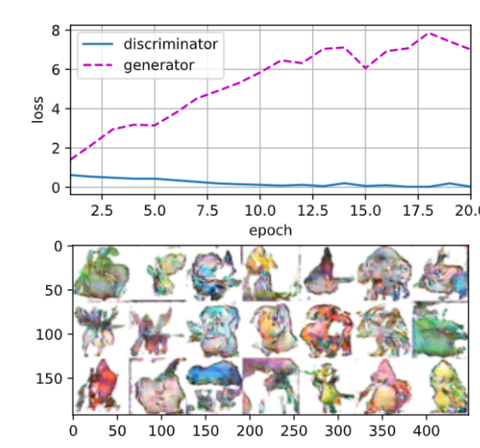

# ** Important **

### It is your responsiblity to ensure your final output (training plot + images) is visible in your submission; you will not recieve full credit otherwise.

#### If you encounter issues with populating your images in a pdf, follow the below instructions

1)  Add a new cell at the bottom of your notebook,
2)  Type some random text into the new cell at the bottom
3)  Highlight the text and then press ctrl + p on your keyboard
4)  Save as a pdf
5)  Submit pdf for submission (A pdf submission is sufficient and html is not required)